# Lab 2

**Goal**: In this lab we will learn how to import our own data into python, build networks, and explore how our modeling choices can affect the analysis and interpretation of the data.

**Before we get started**:
- Activate your python environemnt by selecting your `BIOL4559` kernel.

**After the completion of this lab**
1. List the people with whom you worked with on this lab.
2. Submit to Canvas under the appropriate lab assignment

**How you will be graded**

This activity is out of 10 points. You will be graded on two things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing. ** Examples of good and bad documentation below.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Polars

The two main libraries used for data analysis in python are pandas and polars. Pandas is the more widely used library, but polars is faster and more efficient for larger datasets. Here we will use polars to import and prepare our data for use in networkx.

Lets start by importing the necessary libraries.

In [47]:
# Importing the required packages
import matplotlib.pyplot as plt
import networkx as nx
import polars as pl

To import data using polars, we use the `read_csv` function. This function takes in the file path of the data and returns a polars dataframe. Here we will import the beetle data (cook_social_2020.csv) provided to you.

**A little bit of infomration on the dataset**:

 This dataset `cook_social_2020.csv` lives in `data/CookSocial2020/` alongside a README that documents the full study in detail.

The data comes from a behavioral study of forked fungus beetles (Bolitotherus cornutus) at the Mountain Lake Biological Station here in Virginia. Researchers set up 12 "condos" (mesocosm enclosures), each housing 36 beetles, and observed their social behavior 3 times a day for 21 days in August 2020. Each condo contained an artificial "log" which is a gridded wall (3 rows × 18 columns) where beetles could interact, rest, and lay eggs on fungus brackets, similar to what they'd encounter in the wild.

For reference, here are the behavior codes that are metnioned in the dataset

S = stationary, M = moving
- CRT / MCRT / FCRT = courting
- COP = copulating, G = mate-guarding
- F = fighting, L = laying an egg
- OS = searching for a place to lay an egg

In [48]:
# Read beetle data using polars
df = pl.read_csv("../data/CookSocial2020/cook_social_2020.csv")
print(df)

shape: (75_731, 9)
┌──────────────┬───────┬──────────┬─────┬───┬───────────┬──────────────┬────────────┬──────────────┐
│ datetime     ┆ condo ┆ focal_id ┆ sex ┆ … ┆ grid_cell ┆ cell_locatio ┆ partner_id ┆ partner_inte │
│ ---          ┆ ---   ┆ ---      ┆ --- ┆   ┆ ---       ┆ n            ┆ ---        ┆ raction      │
│ str          ┆ str   ┆ str      ┆ str ┆   ┆ str       ┆ ---          ┆ str        ┆ ---          │
│              ┆       ┆          ┆     ┆   ┆           ┆ str          ┆            ┆ str          │
╞══════════════╪═══════╪══════════╪═════╪═══╪═══════════╪══════════════╪════════════╪══════════════╡
│ 2018-06-27T0 ┆ 6B    ┆ 3PS      ┆ F   ┆ … ┆ A02       ┆ C            ┆ null       ┆ null         │
│ 6:26:00Z     ┆       ┆          ┆     ┆   ┆           ┆              ┆            ┆              │
│ 2018-06-27T0 ┆ 6B    ┆ 3HO      ┆ F   ┆ … ┆ W         ┆ null         ┆ null       ┆ null         │
│ 6:27:00Z     ┆       ┆          ┆     ┆   ┆           ┆              ┆

Now that we have our data imported, we can start to explore it. The beetle data contains observations of social interactions between beetles. Each row in the dataframe represents an interaction between two beetles, identified by their `focal_id` and `partner_id`. The `condo` column indicates the location of the interaction, and the `datetime` column indicates when the interaction occurred.

For now the datetime column is represented as string. We need to convert it to a datetime object so that we can filter the data by date. We can do this using the `to_datetime` function. We then replace the existing datetime column with the new datetime object.

In [49]:
# Convert first object column to datetime
new_col = df["datetime"].str.to_datetime(
    "%Y-%m-%dT%H:%M:%S%Z", strict=False
)  # The arguments explains python what fromat my date colum is in (Years-month-dayTHours:Minutes:Seconds)
df.replace_column(0, new_col)  # Replacing my first column (index = 0) with new_col

# Also drop nulls
df.drop_nulls()

datetime,condo,focal_id,sex,behavior,grid_cell,cell_location,partner_id,partner_interaction
datetime[μs],str,str,str,str,str,str,str,str
2018-06-27 06:32:00,"""6B""","""2MO""","""M""","""CRT""","""C01""","""B""","""3TL""","""Mating Partners"""
2018-06-27 06:32:00,"""6B""","""3TL""","""F""","""CRT""","""C01""","""B""","""2MO""","""Mating Partners"""
2018-06-27 06:32:00,"""6B""","""3TL""","""F""","""CRT""","""C01""","""B""","""3VX""","""5 CM Partners"""
2018-06-27 06:32:00,"""6B""","""3VX""","""F""","""S""","""C01""","""T""","""3TL""","""5 CM Partners"""
2018-06-27 06:32:00,"""6B""","""3VX""","""F""","""S""","""C01""","""T""","""2MO""","""5 CM Partners"""
…,…,…,…,…,…,…,…,…
2020-08-18 22:00:00,"""6B""","""5YN""","""F""","""CRT""","""B18""","""C""","""4K2""","""Mating Partners"""
2020-08-22 23:21:00,"""6B""","""4AW""","""M""","""CRT""","""C18""","""B""","""5AS""","""Mating Partners"""
2020-08-22 23:21:00,"""6B""","""5AS""","""F""","""CRT""","""C18""","""B""","""4AW""","""Mating Partners"""


Our data also contains information about unknown beetles, identified by the `focal_id` and `partner_id` values of 'UK', 'UKM', and 'UKF' (look at the ReadMe file). We will filter these out of our data using the `filter` function. This funtion takes in a boolean (True/False) expression and returns a new dataframe with only the rows that satisfy the expression. We can use bitwise operators to combine multiple boolean expressions as well.

Bitwise operators are used to combine multiple boolean expressions. The most common bitwise operators are:
* & (and): Returns True if both expressions are True
* | (or): Returns True if either expression is True
* ~ (not): Returns True if the expression is False

In [50]:
# Filtering out bad values
bad_values = [
    "UK",
    "UKM",
    "UKF",
]  # List of bad values [Unknown, Unknown Males, Unknown Females]
df = df.filter(
    ~pl.col("focal_id").is_in(bad_values)
)  # ~ converts a FALSE to TRUE and vice versa
df = df.filter(~pl.col("partner_id").is_in(bad_values))

Now that we have cleaned our data, we can start choosing which data we want to use to build our networks. For this lab, we will focus on the interactions that took place in condo '6B' during the month of July 2018. We can filter our data using the `filter` function again.

In [51]:
# Filtering only when condo is 6B
df_6B = df.filter(pl.col("condo") == "6B")

# Filtering for July in 2018
df_6B_2018 = df_6B.filter(pl.col("datetime").dt.year() == 2018)  # Filter for 2018
df_6B_2018 = df_6B_2018.filter(pl.col("datetime").dt.month() == 7)  # Filter for July

We can use a one-line function to do the above task using bitwise operators.

In [52]:
# You can also make use of bitwise operators to do it all at once
df_6B_2018 = df.filter(
    (pl.col("condo") == "6B")
    & (pl.col("datetime").dt.year() == 2018)
    & ((pl.col("datetime").dt.month() == 7))
)

# Think as (Condition 1) & (Condition 2) & (Condition 3), only return TRUE if all three are TRUE for a row.

# Creating Networks

Now that we have our data filtered, we can start to build our networks. We will use the networkx library to build our networks. The first step is to create an empty graph using the `Graph` function (Just like in Lab 1).

In [53]:
# Lets now create our graph
G = nx.Graph()

Now we will add nodes to our graph. We will add all the unique `focal_id` values as nodes in our graph. We can do this using the `add_nodes_from` function to add all the nodes at once.

In [54]:
# Adding all the nodes
G.add_nodes_from(df_6B_2018["focal_id"].to_list())

Now we will add edges to our graph. We will add an edge between two nodes if there is an interaction between them. We can do this using the `add_edges_from` function to add all the edges at once. For now we will edges for all types of interactions. We will filter for specific types of interactions later. We use `rows()` to convert the polars dataframe to a list of tuples, which is the format that the `add_edges_from` function expects.

A faster function to use would be the `iter_rows` function, which returns an iterator over the rows of the dataframe. This is more memory efficient than converting the entire dataframe to a list of tuples.

In [55]:
# Lets create a list of all the edges
edge_list = (df_6B_2018["focal_id", "partner_id"]).rows()

# or
edge_list = df_6B_2018["focal_id", "partner_id"].iter_rows()

# Adding all edges to the network
G.add_edges_from(edge_list)

We can now draw the network using the `draw` function. This function takes in the graph and some optional parameters to customize the appearance of the graph.

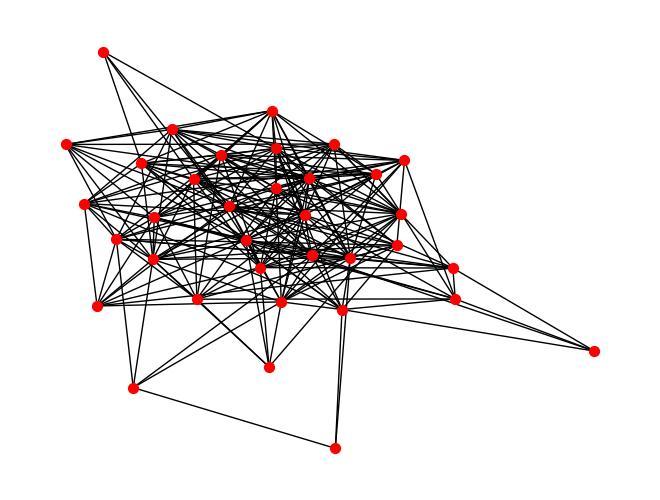

In [56]:
nx.draw(G, with_labels=False, node_size=50, node_color="red")

Lets print some statistics about our network, like the mean degree, clustering coefficient and the density of the network.

In [57]:
n = G.number_of_nodes()  # Calculating number of nodes
m = G.number_of_edges()  # Calculating number of edges

k_list = []  # Empty list to store degree of nodes
for j in G.nodes:  # Looping over all nodes
    k_list.append(G.degree[j])  # Adding degree of each node to the list

k_G = sum(k_list) / len(k_list)  # Finding mean degree
print(f"Mean degree of network: {k_G}")

density_G = m / (n * (n - 1) / 2)  # Finding density
print(f"Density of network: {density_G}")

CC_G = nx.average_clustering(G)  # Finding average CC
print(f"Mean CC of network: {CC_G}")

Mean degree of network: 12.857142857142858
Density of network: 0.37815126050420167
Mean CC of network: 0.4791321877788043


Seems like our network is very well connected. This is likely because we included all types of interactions in our network. Let's try filtering for specific types of interactions and see how that affects the network. Let's start by filtering for only "Touch Partners" interactions.

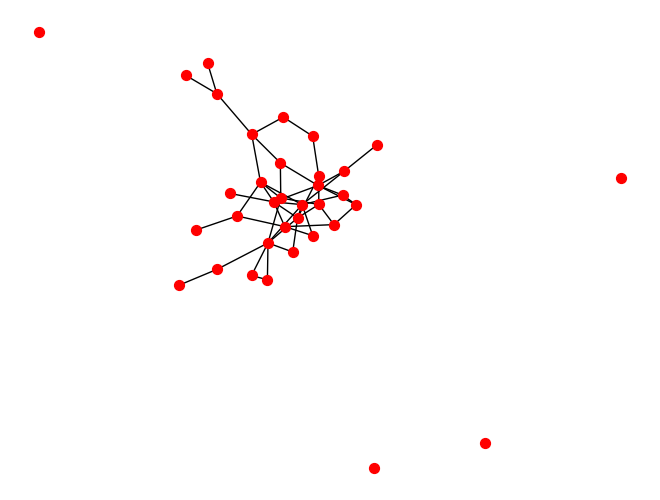

In [58]:
# Filtering edges for only 'Touch Partners'
touching_edge_df = df_6B_2018.filter(pl.col("partner_interaction") == "Touch Partners")
touching_edge_list = (touching_edge_df["focal_id", "partner_id"]).rows()

# Empty graph for the new touch network
Touch_G = nx.Graph()
Touch_G.add_nodes_from(
    df_6B_2018["focal_id"]
)  # Adding nodes (Why do we add from df_6B_2018 and not touching_edge_df)

Touch_G.add_edges_from(touching_edge_list)  # Adding edges

nx.draw(Touch_G, with_labels=False, node_size=50, node_color="red")

Lets reuse the previous code to print out the new statistics for this network.

In [59]:
# Refactoring the previous code cell with stats
n = Touch_G.number_of_nodes()
m = Touch_G.number_of_edges()

k_list = []
for i in Touch_G.nodes:
    k_list.append(Touch_G.degree[i])

k_G = sum(k_list) / len(k_list)
print(f"Mean degree of network G: {k_G}")

density_G = m / (n * (n - 1) / 2)
print(f"Density of network G: {density_G}")

CC_G = nx.average_clustering(Touch_G)
print(f"Mean CC of network G: {CC_G}")

Mean degree of network G: 2.742857142857143
Density of network G: 0.08067226890756303
Mean CC of network G: 0.14435374149659863


Now the network is much less connected. On average it seems like each beetle only touches ~3 other beetles. This is likely a more accurate representation of the social structure of the beetles. We can also try filtering for other types of interactions and see how that affects the network.

Then we can start having some fun, we can try and figure out if there is any correlation between the different types of interactions. For example, do beetles that touch each other also tend to be mates? We can use the Jaccard index to calculate the similarity between the two networks. The Jaccard index is defined as the number of edges in the intersection of the two networks (i.e. present in both networks) divided by the number of edges in the union of the two networks (i.e. all the edges present in total from both networks).

Here is an example of how to calculate the Jaccard index using two example networks.
```python
# Creating network 1
G1 = nx.Graph()
G1.add_nodes_from([1, 2, 3, 4, 5]) # Adding nodes
G1.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)]) # Adding edges

# Creating network 2
G2 = nx.Graph()
G2.add_nodes_from([1, 2, 3, 4, 5]) # Adding nodes
G2.add_edges_from([(2, 3), (3, 4), (4, 5)]) # Adding edges

# Calculating Jaccard index
edges_G1 = set(G1.edges())
edges_G2 = set(G2.edges())

intersection_size = len(edges_G1.intersection(edges_G2)) # Number of edges in both networks
union_size = len(edges_G1.union(edges_G2)) # Number of edges in either network
jaccard_index = intersection / union

print(f'Jaccard index: {jaccard_index}')
```

## Graded Activity

* Load the data from CookSocial2020 dataset and clean the data to remove any bad values (like unknown males, females).
* Create a network for the year 2020, and a condo of your choosing (mention which condo you chose).
* Draw the network for different mating interactions (Mating Partners, Touch Partners, and 5 CM Partners), try to remove any isolates. Tell us what do you think, should isolates be considered while analysing networks or not and why? (Hint: Check the documentation for networkx to see how to remove isolates).
* Check how the network statistics (degree, clustering coefficient, and density) change with different mating interactions.
* What do these statistics tell you?
* What would these different representations of the same data be useful for? State applications for each type of network you draw.

(Optional, Ungraded activity) Check whether different interactions have a correlation, does a beetle with more Touch partners also get more Mates? (Hint: Calculate the Jaccard similarity between the edges of the two networks).

**Student answer here**

In [60]:
#read csv and show data types
df = pl.read_csv("../data/CookSocial2020/cook_social_2020.csv")
df.head

#drop nulls and convert relevant columns to correct datatypes
df = df.drop_nulls()
new_col = df["datetime"].str.to_datetime("%Y-%m-%dT%H:%M:%S%Z", strict=False)
df.replace_column(0, new_col)
df.head

#filter out bad values
bad_values = [
    "UK",
    "UKM",
    "UKF",
]
df = df.filter(~pl.col("focal_id").is_in(bad_values))  
df = df.filter(~pl.col("partner_id").is_in(bad_values))
df.head

#filtering data for 2020 condo 1A for each interaction
df_1A_2020 = df.filter(
    (pl.col("condo") == "1A") & 
    (pl.col("datetime").dt.year() == 2020)
)
df_1A_2020_mating = df.filter((pl.col('partner_interaction') == 'Mating Partners'))
df_1A_2020_touch = df.filter((pl.col('partner_interaction') == 'Touch Partners'))
df_1A_2020_5cm = df.filter((pl.col('partner_interaction') == '5 CM Partners'))

In [ ]:
#creating networks and remove isolates 
G_mating = nx.Graph()
G_mating.add_nodes_from(df_1A_2020_mating["focal_id"].to_list())
G_mating.add_edges_from(df_1A_2020_mating["focal_id", "partner_id"].iter_rows())
G_mating.remove_nodes_from(list(nx.isolates(G_mating)))

G_touch = nx.Graph()
G_touch.add_nodes_from(df_1A_2020_touch["focal_id"].to_list())
G_touch.add_edges_from(df_1A_2020_touch["focal_id", "partner_id"].iter_rows())
G_touch.remove_nodes_from(list(nx.isolates(G_touch)))

G_5cm = nx.Graph()
G_5cm.add_nodes_from(df_1A_2020_5cm["focal_id"].to_list())
G_5cm.add_edges_from(df_1A_2020_5cm["focal_id", "partner_id"].iter_rows())
G_5cm.remove_nodes_from(list(nx.isolates(G_5cm)))


Isolates should be considered when analysing networks as all nodes within a network have potential to provide insight and should not be discredited because they are not connected to other parts of the network. i.e. a large amount of isolates could show that interactions between nodes is actual rare in certain networks etc. 


Text(0.5, 1.0, '5cm')

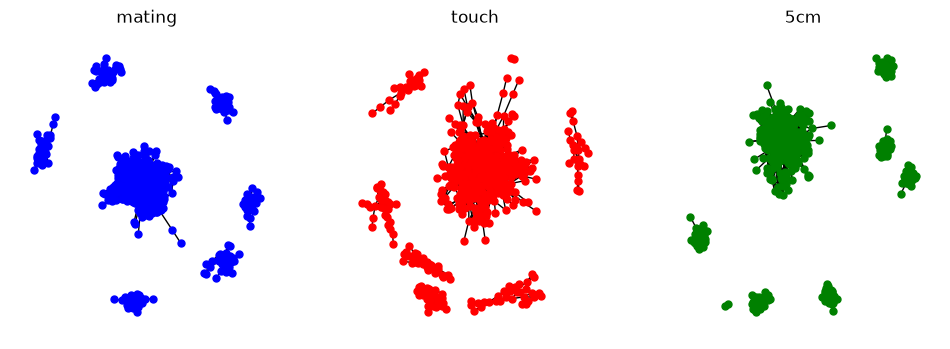

In [67]:
#draw networks
plt.figure(figsize=(12,4))
plt.subplot(1, 3, 1)
nx.draw(G_mating, with_labels=False, node_size=25, node_color="blue")
plt.title('mating')

plt.subplot(1, 3, 2)
nx.draw(G_touch, with_labels=False, node_size=25, node_color="red")
plt.title('touch')

plt.subplot(1, 3, 3)
nx.draw(G_5cm, with_labels=False, node_size=25, node_color="green")
plt.title('5cm')

In [64]:
#mating network statistics
n = G_mating.number_of_nodes()
m = G_mating.number_of_edges()

k_list = []
for j in G_mating.nodes:
    k_list.append(G_mating.degree[j])

k_G = sum(k_list) / len(k_list)  
print(f"mating mean degree: {k_G:.2f}")

density_G = m / (n * (n - 1) / 2) 
print(f"mating density: {density_G:.2f}")

CC_G = nx.average_clustering(G_mating)
print(f"mating mean clustering coefficient: {CC_G:.2f}")


mating mean degree: 9.62
mating density: 0.01
mating mean clustering coefficient: 0.00


In [65]:
#touch network statistics
n = G_touch.number_of_nodes()
m = G_touch.number_of_edges()

k_list = []
for j in G_touch.nodes:
    k_list.append(G_touch.degree[j])

k_G = sum(k_list) / len(k_list)  
print(f"touch mean degree: {k_G:.2f}")

density_G = m / (n * (n - 1) / 2) 
print(f"touch density: {density_G:.2f}")

CC_G = nx.average_clustering(G)
print(f"touch mean clustering coefficient: {CC_G:.2f}")

touch mean degree: 5.59
touch density: 0.01
touch mean clustering coefficient: 0.48


In [66]:
#5cm network statistics
n = G_5cm.number_of_nodes()
m = G_5cm.number_of_edges()

k_list = []
for j in G_5cm.nodes:
    k_list.append(G_5cm.degree[j])

k_G = sum(k_list) / len(k_list)  
print(f"5cm mean degree: {k_G:.2f}")

density_G = m / (n * (n - 1) / 2) 
print(f"5cm density: {density_G:.2f}")

CC_G = nx.average_clustering(G_5cm)
print(f"5cm mean clustering coefficient: {CC_G:.2f}")

5cm mean degree: 16.01
5cm density: 0.02
5cm mean clustering coefficient: 0.39


Across all three interactions, the mean degrees are relatively high, meaning that each beetle interacted with seveal other beetles, however the density and mean CC of each is much lower, indicating that the beetles mostly interacted with the same beetles and said beetles did not interact with those outside of their neighbors

These representations can evidently show networks of different types of interactions within the data, but using these representations we can compare and contrast the different interactions easier. We can see that in all networks there are clusters that are not connected to the largest cluster and size differences that indicate just because most beetles had a certain interaction, does not mean that they had another interaction.

In [71]:
#Jaccard index for mating and touch
intersection = len(set(G_mating.edges()).intersection(set(G_touch.edges())))
union = len(set(G_mating.edges()).union(set(G_touch.edges())))
jaccard_index = intersection / union 

print(f'Jaccard index: {jaccard_index:.2f}')

Jaccard index: 0.07
